# Ensemble Decision Trees Demo
This notebook demonstrates:
1. Training sklearn BaggingClassifier and AdaBoostClassifier
2. Saving ensemble models to JSON
3. Loading and using custom ensemble classes

## 1. Import Libraries and Load Data

In [61]:
import numpy as np
import pandas as pd
import json
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import sys
sys.path.append('..')

from helpers.save_model_params import extract_bagging_to_dict, extract_boosting_to_dict
from helpers.tfidf_vectorizer import TfidfVectorizer
from helpers.bow_vectorizer import BowVectorizer
from models.decision_tree import BaggingTreeModel, BoostingTreeModel

In [62]:
# Configure data paths
train_data_path = 'data/train_data_raw.csv'
val_data_path = 'data/validation_data_raw.csv'
test_data_path = 'data/test_data_raw.csv'
random_seed = 42
normalize_data = True

print("Data paths configured")
print(f"Train: {train_data_path}")
print(f"Validation: {val_data_path}")
print(f"Test: {test_data_path}")

vectorizer = BowVectorizer

Data paths configured
Train: data/train_data_raw.csv
Validation: data/validation_data_raw.csv
Test: data/test_data_raw.csv


## 2. Prepare Data

In [63]:
# Initialize BowVectorizer and build vocabulary
dataloader = vectorizer(seed=random_seed, truncate_length=8)
dataloader.build_vocab(train_data_path, verbose=True)
# dataloader.build_svd(train_data_path, normalize=normalize_data, verbose=True)

print(f"\nVocabulary size: {dataloader.get_vocab_size()}")

Building vocabulary from data/train_data_raw.csv...
Reading data from data/train_data_raw.csv...
Cleaning data...

Vocabulary size: 3162


In [64]:
# Generate TF-IDF features for train, validation, and test sets
X_train, y_train = dataloader.generate_Xt(train_data_path, normalize=normalize_data, verbose=True)
X_val, y_val = dataloader.generate_Xt(val_data_path, normalize=normalize_data, verbose=True)
X_test, y_test = dataloader.generate_Xt(test_data_path, normalize=normalize_data, verbose=True)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Generating features and targets from data/train_data_raw.csv...
Reading data from data/train_data_raw.csv...
Cleaning data...
Generating features and targets from data/validation_data_raw.csv...
Reading data from data/validation_data_raw.csv...
Cleaning data...
Generating features and targets from data/test_data_raw.csv...
Reading data from data/test_data_raw.csv...
Cleaning data...

X_train shape: (648, 3182)
y_train shape: (648,)
X_val shape: (150, 3182)
y_val shape: (150,)
X_test shape: (27, 3182)
y_test shape: (27,)
Number of classes: 3


## 3. Train Bagging Ensemble

In [65]:
# Create base estimator
base_tree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=2,
    random_state=random_seed,
    criterion='entropy'
)

# Create BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=20,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=True,
    random_state=random_seed,
    n_jobs=-1,
    verbose=1
)

print("Training Bagging Ensemble...")
bagging_model.fit(X_train, y_train)
print("Training complete!")

Training Bagging Ensemble...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  20 | elapsed:    1.7s remaining:   15.7s


Training complete!


[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    1.9s finished


In [66]:
# Evaluate bagging model
bagging_train_pred = bagging_model.predict(X_train)
bagging_val_pred = bagging_model.predict(X_val)
# bagging_test_pred = bagging_model.predict(X_test)

print("Sklearn BaggingClassifier Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, bagging_val_pred):.4f}")
# print(f"Test Accuracy: {accuracy_score(y_test, bagging_test_pred):.4f}")
print(f"OOB Score: {bagging_model.oob_score_:.4f}")

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  20 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    0.0s finished


Sklearn BaggingClassifier Performance:
Training Accuracy: 0.9105
Validation Accuracy: 0.5800
OOB Score: 0.6111


## 4. Save Bagging Model to JSON

In [67]:
# Generate feature names
vocab_size = dataloader.get_vocab_size()
feature_names = [f"feature_{i}" for i in range(len(X_train[0]))]

# Extract model to dictionary
bagging_dict = extract_bagging_to_dict(bagging_model, feature_names=feature_names)

# Save to JSON file
bagging_output_path = '../models/fitted_bagging.json'
with open(bagging_output_path, 'w') as f:
    json.dump(bagging_dict, f, indent=2)

print(f"Bagging model saved to: {bagging_output_path}")
print(f"\nModel metadata:")
for key, value in bagging_dict['metadata'].items():
    if key != 'feature_names' and key != 'classes':
        print(f"  {key}: {value}")

Bagging model saved to: ../models/fitted_bagging.json

Model metadata:
  model_type: BaggingClassifier
  n_estimators: 20
  n_features: 3182
  n_classes: 3
  max_samples: 0.8
  max_features: 0.8
  bootstrap: True
  bootstrap_features: False
  oob_score: True
  warm_start: False
  random_state: 42
  oob_score_value: 0.6111111111111112


## 5. Load and Test Custom Bagging Model

In [68]:
# Load the custom bagging model
custom_bagging = BaggingTreeModel('../models/fitted_bagging.json')

Bagging ensemble loaded from: ../models/fitted_bagging.json
Number of trees: 20


In [69]:
# Make predictions with custom model
custom_bagging_train_pred = custom_bagging.predict(X_train)
custom_bagging_val_pred = custom_bagging.predict(X_val)

print(X_train)

print("prediction stats:", np.unique(custom_bagging_train_pred, return_counts=True))
# custom_bagging_test_pred = custom_bagging.predict(X_test)

print("Custom BaggingTreeModel Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, custom_bagging_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, custom_bagging_val_pred):.4f}")
# print(f"Test Accuracy: {accuracy_score(y_test, custom_bagging_test_pred):.4f}")

[[0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 1. 0.]]
prediction stats: (array([0, 1, 2]), array([230, 195, 223]))
Custom BaggingTreeModel Performance:
Training Accuracy: 0.9105
Validation Accuracy: 0.5800


In [70]:
# Verify predictions match
train_match = np.array_equal(bagging_train_pred, custom_bagging_train_pred)
val_match = np.array_equal(bagging_val_pred, custom_bagging_val_pred)
# test_match = np.array_equal(bagging_test_pred, custom_bagging_test_pred)

print("Bagging Prediction Comparison:")
print(f"Training predictions match: {train_match}")
print(f"Validation predictions match: {val_match}")
# print(f"Test predictions match: {test_match}")

if not val_match:
    diff_count = np.sum(bagging_val_pred != custom_bagging_val_pred)
    print(f"\nValidation differences: {diff_count} out of {len(y_val)}")
    print(f"Difference rate: {diff_count / len(y_val) * 100:.2f}%")

Bagging Prediction Comparison:
Training predictions match: True
Validation predictions match: True


In [71]:
boosting_hyp = {
    'truncate_length': [3, 4, 5],
    'n_estimators': [25, 30],
    'learning_rate': [0.4, 0.5, 0.6],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 6, 7],
    'criterion': ['gini', 'entropy']
}

def tune_boosting_hyp():
    import itertools

    dataloaders = {}
    for trunc_len in boosting_hyp['truncate_length']:
        dataloader = vectorizer(seed=random_seed, truncate_length=trunc_len)
        dataloader.build_vocab(train_data_path, verbose=False)
        dataloaders[trunc_len] = dataloader

    best_val_acc = 0.0
    best_config = None

    key_list = list(boosting_hyp.keys())
    value_lists = [boosting_hyp[key] for key in key_list]
    for values in itertools.product(*value_lists):
        config = dict(zip(key_list, values))
        print(config)

        X_tune_train, y_tune_train = dataloaders[config['truncate_length']].generate_Xt(train_data_path, normalize=normalize_data, verbose=False)
        X_tune_val, y_tune_val = dataloaders[config['truncate_length']].generate_Xt(val_data_path, normalize=normalize_data, verbose=False)

        base_stump = DecisionTreeClassifier(
            max_depth=config['max_depth'],
            min_samples_split=config['min_samples_split'],
            random_state=random_seed,
            criterion=config['criterion']
        )
        boosting_model = AdaBoostClassifier(
            estimator=base_stump,
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            random_state=random_seed
        )
        boosting_model.fit(X_tune_train, y_tune_train)
        val_pred = boosting_model.predict(X_tune_val)
        val_acc = accuracy_score(y_tune_val, val_pred)
        print(f"Validation Accuracy: {val_acc:.4f}\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_config = config
    
    print(f"Best Validation Accuracy: {best_val_acc:.4f} with config: {best_config}")

## 6. Train Boosting Ensemble (AdaBoost)

In [72]:
# tune_boosting_hyp()

In [73]:
# Create base estimator for AdaBoost (typically shallow trees)
base_stump = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=2,
    random_state=random_seed,
    criterion='entropy'
)

# Create AdaBoostClassifier
boosting_model = AdaBoostClassifier(
    estimator=base_stump,
    n_estimators=10,
    learning_rate=1.0,
    random_state=random_seed
)

print("Training AdaBoost Ensemble...")
boosting_model.fit(X_train, y_train)
print("Training complete!")

Training AdaBoost Ensemble...
Training complete!


In [74]:
# Evaluate boosting model
boosting_train_pred = boosting_model.predict(X_train)
boosting_val_pred = boosting_model.predict(X_val)
boosting_test_pred = boosting_model.predict(X_test)

print("Sklearn AdaBoostClassifier Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, boosting_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, boosting_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, boosting_test_pred):.4f}")

Sklearn AdaBoostClassifier Performance:
Training Accuracy: 0.9954
Validation Accuracy: 0.7133
Test Accuracy: 0.7407


## 7. Save Boosting Model to JSON

In [75]:
# Extract model to dictionary
boosting_dict = extract_boosting_to_dict(boosting_model, feature_names=feature_names)

# Save to JSON file
boosting_output_path = '../models/fitted_boosting.json'
with open(boosting_output_path, 'w') as f:
    json.dump(boosting_dict, f, indent=2)

print(f"Boosting model saved to: {boosting_output_path}")
print(f"\nModel metadata:")
for key, value in boosting_dict['metadata'].items():
    if key != 'feature_names' and key != 'classes':
        print(f"  {key}: {value}")

print(f"\nEstimator weights (first 10): {boosting_dict['tree_weights'][:10]}")

Boosting model saved to: ../models/fitted_boosting.json

Model metadata:
  model_type: AdaBoostClassifier
  n_estimators: 10
  n_features: 3182
  n_classes: 3
  learning_rate: 1.0
  algorithm: deprecated
  random_state: 42

Estimator weights (first 10): [3.684028999980187, 4.2568634917198755, 3.7967277727896835, 4.820646885904011, 2.1262318776512745, 2.1272684681050813, 1.695042592968662, 1.6394561793061553, 1.5638469939053927, 1.51720039558267]


## 8. Load and Test Custom Boosting Model

In [76]:
# Load the custom boosting model
custom_boosting = BoostingTreeModel('../models/fitted_boosting.json')

Boosting ensemble loaded from: ../models/fitted_boosting.json
Number of trees: 10


In [77]:
# Make predictions with custom model
custom_boosting_train_pred = custom_boosting.predict(X_train)
custom_boosting_val_pred = custom_boosting.predict(X_val)
# custom_boosting_test_pred = custom_boosting.predict(X_test)

print("Custom BoostingTreeModel Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, custom_boosting_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, custom_boosting_val_pred):.4f}")
# print(f"Test Accuracy: {accuracy_score(y_test, custom_boosting_test_pred):.4f}")

Custom BoostingTreeModel Performance:
Training Accuracy: 0.9954
Validation Accuracy: 0.7133


In [78]:
# Verify predictions match
val_match = np.array_equal(boosting_val_pred, custom_boosting_val_pred)
# test_match = np.array_equal(boosting_test_pred, custom_boosting_test_pred)

print("Boosting Prediction Comparison:")
print(f"Validation predictions match: {val_match}")
# print(f"Test predictions match: {test_match}")

if not val_match:
    diff_count = np.sum(boosting_val_pred != custom_boosting_val_pred)
    print(f"Number of different predictions: {diff_count} out of {len(y_val)}")
    print(f"Difference rate: {diff_count / len(y_val) * 100:.2f}%")

Boosting Prediction Comparison:
Validation predictions match: True


## 9. Compare All Models

In [79]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Bagging (sklearn)', 'Bagging (custom)', 'Boosting (sklearn)', 'Boosting (custom)'],
    'Train Acc': [
        accuracy_score(y_train, bagging_train_pred),
        accuracy_score(y_train, custom_bagging_train_pred),
        accuracy_score(y_train, boosting_train_pred),
        accuracy_score(y_train, custom_boosting_train_pred)
    ],
    'Val Acc': [
        accuracy_score(y_val, bagging_val_pred),
        accuracy_score(y_val, custom_bagging_val_pred),
        accuracy_score(y_val, boosting_val_pred),
        accuracy_score(y_val, custom_boosting_val_pred)
    ],
    # 'Test Acc': [
    #     np.nan,  # Bagging test not yet run
    #     np.nan,  # Bagging test not yet run
    #     accuracy_score(y_test, boosting_test_pred),
    #     accuracy_score(y_test, custom_boosting_test_pred)
    # ]
})

print("\nModel Comparison:")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)
print("\nNote: Bagging test predictions not yet run (still tuning hyperparameters)")


Model Comparison:
             Model  Train Acc  Val Acc
 Bagging (sklearn)   0.910494 0.580000
  Bagging (custom)   0.910494 0.580000
Boosting (sklearn)   0.995370 0.713333
 Boosting (custom)   0.995370 0.713333

Note: Bagging test predictions not yet run (still tuning hyperparameters)


## 10. Visualize Model Performance

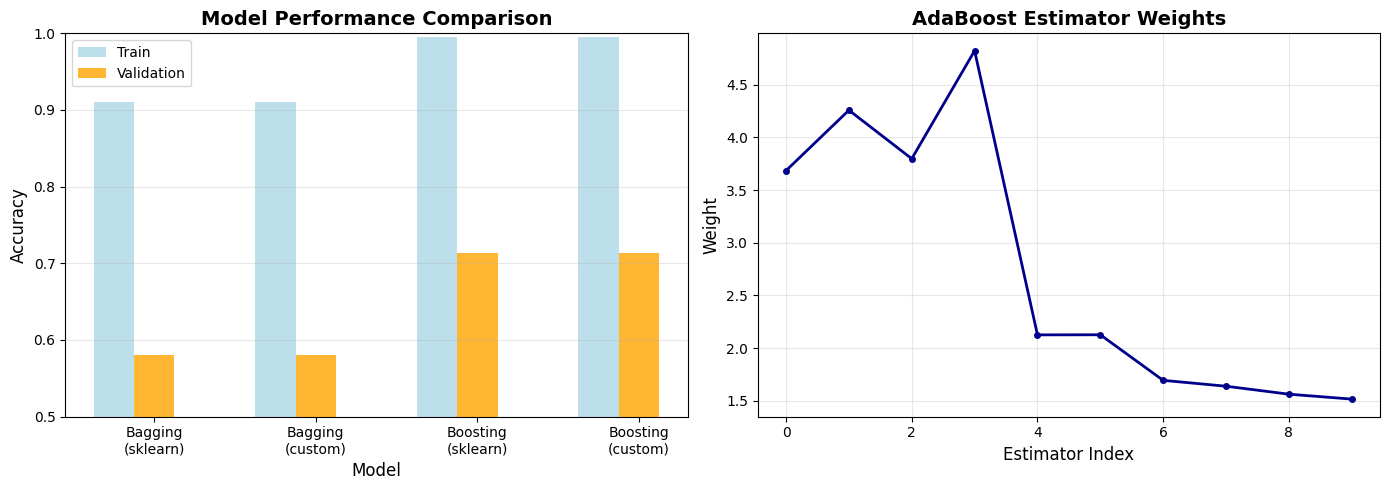


Boosting model uses 10 estimators
Weight range: [1.5172, 4.8206]
Mean weight: 2.7227


In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
models = ['Bagging\n(sklearn)', 'Bagging\n(custom)', 'Boosting\n(sklearn)', 'Boosting\n(custom)']
x = np.arange(len(models))
width = 0.25

train_accs = comparison_df['Train Acc'].values
val_accs = comparison_df['Val Acc'].values
# test_accs = comparison_df['Test Acc'].values

axes[0].bar(x - width, train_accs, width, label='Train', color='lightblue', alpha=0.8)
axes[0].bar(x, val_accs, width, label='Validation', color='orange', alpha=0.8)
# Only plot test bars where we have data (not NaN)
# test_mask = ~np.isnan(test_accs)
# axes[0].bar(x[test_mask] + width, test_accs[test_mask], width, label='Test', color='lightgreen', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

# Plot 2: Estimator weights for boosting
weights = boosting_dict['tree_weights']
axes[1].plot(range(len(weights)), weights, marker='o', linewidth=2, markersize=4, color='darkblue')
axes[1].set_xlabel('Estimator Index', fontsize=12)
axes[1].set_ylabel('Weight', fontsize=12)
axes[1].set_title('AdaBoost Estimator Weights', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBoosting model uses {len(weights)} estimators")
print(f"Weight range: [{min(weights):.4f}, {max(weights):.4f}]")
print(f"Mean weight: {np.mean(weights):.4f}")